# VoiceBank Speech Enhancement: Training the UNet Speech Enhancement Model

**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.


**Notebook Overview**:
Complete training system with evaluation metrics and monitoring
- Load the dataset (train/val split)
- Initialize the DataLoader
- Define the UNet model
- Set the optimizer & loss function
- Train for a few epochs with progress logging
- Save the model weights


**Next Steps**:
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from tqdm import tqdm
import wandb  # For experiment tracking
from collections import defaultdict
import pickle
import json


data_root = "/kaggle/input/voicebank-demand"

In [2]:
# FeatureDataset and UNet model imported from their corresponding notebooks
import sys

sys.path.append("/kaggle/usr/lib/models")
sys.path.append("/kaggle/usr/lib/dataset_class")
from models import UNet, create_model
from dataset_class import create_dataloaders

class NumpyEncoder(json.JSONEncoder):
    """Custom JSON encoder for numpy types"""
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int32, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float32, np.float64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [3]:
class SpectralLoss(nn.Module):
    """Combined spectral loss functions for speech enhancement"""
    
    def __init__(self, l1_weight=1.0, l2_weight=0.5, spectral_weight=0.3):
        super(SpectralLoss, self).__init__()
        self.l1_weight = l1_weight
        self.l2_weight = l2_weight  
        self.spectral_weight = spectral_weight
        
        self.l1_loss = nn.L1Loss()
        self.l2_loss = nn.MSELoss()
    
    def spectral_convergence(self, x_mag, y_mag):
        """Spectral convergence loss"""
        return torch.norm(y_mag - x_mag, p='fro') / torch.norm(y_mag, p='fro')
    
    def log_stft_magnitude_loss(self, x_mag, y_mag):
        """Log STFT magnitude loss"""
        return self.l1_loss(torch.log(x_mag + 1e-7), torch.log(y_mag + 1e-7))
    
    def forward(self, pred, target):
        """
        Args:
            pred: Predicted spectrogram [B, C, F, T]
            target: Target clean spectrogram [B, C, F, T]
        """
        # Basic losses
        l1_loss = self.l1_loss(pred, target)
        l2_loss = self.l2_loss(pred, target)
        
        # Spectral losses (convert dB back to magnitude)
        pred_mag = torch.exp(pred)  # Assuming input is in log scale
        target_mag = torch.exp(target)
        
        spec_conv_loss = self.spectral_convergence(pred_mag, target_mag)
        log_stft_loss = self.log_stft_magnitude_loss(pred_mag, target_mag)
        
        total_loss = (self.l1_weight * l1_loss + 
                     self.l2_weight * l2_loss +
                     self.spectral_weight * (spec_conv_loss + log_stft_loss))
        
        return total_loss, {
            'l1_loss': l1_loss.item(),
            'l2_loss': l2_loss.item(),
            'spectral_conv': spec_conv_loss.item(),
            'log_stft': log_stft_loss.item()
        }

In [4]:
class SimplifiedSpectralLoss(nn.Module):
    """
    Simplified loss that works well for dB-scale spectrograms
    Removes the problematic spectral convergence component
    """
    
    def __init__(self, l1_weight=0.7, l2_weight=0.3):
        super(SimplifiedSpectralLoss, self).__init__()
        self.l1_weight = l1_weight
        self.l2_weight = l2_weight
        self.l1_loss = nn.L1Loss()
        self.l2_loss = nn.MSELoss()
    
    def forward(self, pred, target):
        """Simple but effective loss for dB spectrograms"""
        l1_loss = self.l1_loss(pred, target)
        l2_loss = self.l2_loss(pred, target)
        
        total_loss = self.l1_weight * l1_loss + self.l2_weight * l2_loss
        
        return total_loss, {
            'l1_loss': l1_loss.item(), 'l2_loss': l2_loss.item()
        }
            

In [5]:
class SNRLoss(nn.Module):
    """SNR-based loss function"""
    
    def __init__(self, eps=1e-8):
        super(SNRLoss, self).__init__()
        self.eps = eps
    
    def forward(self, pred, target):
        """
        Calculate negative SNR as loss (higher SNR = lower loss)
        """
        # Signal power
        signal_power = torch.mean(target ** 2, dim=[2, 3], keepdim=True)
        
        # Noise power (difference between prediction and target)
        noise_power = torch.mean((pred - target) ** 2, dim=[2, 3], keepdim=True)
        
        # SNR in dB
        snr = 10 * torch.log10(signal_power / (noise_power + self.eps))
        
        # Return negative SNR as loss (minimize negative SNR = maximize SNR)
        return -torch.mean(snr)

In [6]:
def calculate_metrics(pred, target, eps=1e-8):
    """Calculate evaluation metrics"""
    
    # Convert to numpy if needed
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    if isinstance(target, torch.Tensor):
        target = target.detach().cpu().numpy()
    
    # Flatten for computation
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    
    # SNR calculation
    signal_power = np.mean(target_flat ** 2)
    noise_power = np.mean((pred_flat - target_flat) ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + eps))
    
    # MSE
    mse = np.mean((pred_flat - target_flat) ** 2)
    
    # MAE  
    mae = np.mean(np.abs(pred_flat - target_flat))
    
    # Pearson correlation
    correlation = np.corrcoef(pred_flat, target_flat)[0, 1]
    
    return {
        'snr': snr,
        'mse': mse,
        'mae': mae,
        'correlation': correlation
    }

In [7]:
class EarlyStopping:
    """Early stopping utility"""
    
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_weights = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            self.early_stop = True
            if self.restore_best_weights and self.best_weights is not None:
                model.load_state_dict(self.best_weights)
    
    def save_checkpoint(self, model):
        """Save model weights"""
        self.best_weights = model.state_dict().copy()


In [8]:
class SpeechEnhancementTrainer:
    """Complete training pipeline for speech enhancement"""
    
    def __init__(self, model, train_loader, val_loader, test_loader=None,
                 loss_fn=None, optimizer=None, scheduler=None, device=None,
                 checkpoint_dir='checkpoints', use_wandb=False):
        
        self.model = model
        self.train_loader = train_loader  
        self.val_loader = val_loader
        self.test_loader = test_loader
        
        # Device setup
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        
        # Loss function
        self.loss_fn = loss_fn or SimplifiedSpectralLoss()
        
        # Optimizer
        self.optimizer = optimizer or optim.Adam(
            model.parameters(), lr=1e-3, weight_decay=1e-5
        )
        
        # Scheduler
        self.scheduler = scheduler or ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        
        # Checkpointing
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        print(f"💾 Checkpoints will be saved to: {checkpoint_dir}")
        
        # Monitoring
        self.use_wandb = use_wandb
        if use_wandb:
            wandb.init(project="speech-enhancement", config={
                'model': model.__class__.__name__,
                'optimizer': optimizer.__class__.__name__,
                'loss': loss_fn.__class__.__name__,
                'device': str(device)
            })
        
        # Training history
        self.history = defaultdict(list)
        self.best_val_loss = float('inf')
        
    def train_epoch(self):
        """Train for one epoch"""
        self.model.train()
        
        epoch_loss = 0.0
        epoch_metrics = defaultdict(list)
        
        pbar = tqdm(self.train_loader, desc='Training')
        
        for batch_idx, (noisy, clean) in enumerate(pbar):
            noisy, clean = noisy.to(self.device), clean.to(self.device)
            
            # Forward pass
            self.optimizer.zero_grad()
            pred = self.model(noisy)
            
            # Calculate loss
            if isinstance(self.loss_fn, SimplifiedSpectralLoss):
                loss, loss_components = self.loss_fn(pred, clean)
                for key, value in loss_components.items():
                    epoch_metrics[key].append(value)
            else:
                loss = self.loss_fn(pred, clean)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            epoch_loss += loss.item()
            
            # Calculate metrics
            with torch.no_grad():
                metrics = calculate_metrics(pred, clean)
                for key, value in metrics.items():
                    if not np.isnan(value):
                        epoch_metrics[key].append(value)
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'snr': f'{metrics.get("snr", 0):.2f}dB'
            })
        
        # Calculate epoch averages
        avg_loss = epoch_loss / len(self.train_loader)
        avg_metrics = {key: np.mean(values) for key, values in epoch_metrics.items()}
        
        return avg_loss, avg_metrics
    
    def validate_epoch(self):
        """Validate for one epoch"""
        self.model.eval()
        
        epoch_loss = 0.0
        epoch_metrics = defaultdict(list)
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc='Validation')
            
            for noisy, clean in pbar:
                noisy, clean = noisy.to(self.device), clean.to(self.device)
                
                # Forward pass
                pred = self.model(noisy)
                
                # Calculate loss
                if isinstance(self.loss_fn, SimplifiedSpectralLoss):
                    loss, loss_components = self.loss_fn(pred, clean)
                    for key, value in loss_components.items():
                        epoch_metrics[key].append(value)
                else:
                    loss = self.loss_fn(pred, clean)
                
                epoch_loss += loss.item()
                
                # Calculate metrics
                metrics = calculate_metrics(pred, clean)
                for key, value in metrics.items():
                    if not np.isnan(value):
                        epoch_metrics[key].append(value)
                
                pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'snr': f'{metrics.get("snr", 0):.2f}dB'
                })
        
        # Calculate epoch averages
        avg_loss = epoch_loss / len(self.val_loader)
        avg_metrics = {key: np.mean(values) for key, values in epoch_metrics.items()}
        
        return avg_loss, avg_metrics
    
    def train(self, epochs, early_stopping=None, save_every=5):
        """Complete training loop"""
        
        print(f"🚀 Starting training for {epochs} epochs")
        print(f"📱 Device: {self.device}")
        print(f"🧠 Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        
        start_time = time.time()
        
        for epoch in range(epochs):
            epoch_start = time.time()
            
            print(f"\n📅 Epoch {epoch+1}/{epochs}")
            print("=" * 50)
            
            # Training
            train_loss, train_metrics = self.train_epoch()
            
            # Validation
            val_loss, val_metrics = self.validate_epoch()
            
            # Update scheduler
            if isinstance(self.scheduler, ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()
            
            # Record history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            
            for key, value in train_metrics.items():
                self.history[f'train_{key}'].append(value)
            for key, value in val_metrics.items():
                self.history[f'val_{key}'].append(value)
            
            # Print epoch summary
            epoch_time = time.time() - epoch_start
            
            print(f"\n📊 Epoch {epoch+1} Results:")
            print(f"   Train Loss: {train_loss:.4f}")
            print(f"   Val Loss:   {val_loss:.4f}")
            print(f"   Train SNR:  {train_metrics.get('snr', 0):.2f} dB")
            print(f"   Val SNR:    {val_metrics.get('snr', 0):.2f} dB")
            print(f"   Time:       {epoch_time:.1f}s")
            print(f"   LR:         {self.optimizer.param_groups[0]['lr']:.2e}")
            
            # Wandb logging
            if self.use_wandb:
                wandb.log({
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'train_snr': train_metrics.get('snr', 0),
                    'val_snr': val_metrics.get('snr', 0),
                    'learning_rate': self.optimizer.param_groups[0]['lr'],
                    'epoch_time': epoch_time
                })
            
            # Save checkpoint
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.save_checkpoint(epoch + 1, is_best=True)
                print(f"   💾 New best model saved! (Val Loss: {val_loss:.4f})")
            
            if (epoch + 1) % save_every == 0:
                self.save_checkpoint(epoch + 1, is_best=False)
            
            # Early stopping check
            if early_stopping:
                early_stopping(val_loss, self.model)
                if early_stopping.early_stop:
                    print(f"🛑 Early stopping triggered at epoch {epoch+1}")
                    break
        
        total_time = time.time() - start_time
        print(f"\n✅ Training completed in {total_time/60:.1f} minutes")
        
        # Final evaluation on test set
        if self.test_loader:
            print("\n🧪 Evaluating on test set...")
            test_results = self.evaluate_test_set()
            print(f"Test Results: {test_results}")
        
        return self.history
    
    def save_checkpoint(self, epoch, is_best=False):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'best_val_loss': self.best_val_loss,
            'history': dict(self.history)
        }
        
        # Regular checkpoint
        checkpoint_path = os.path.join(self.checkpoint_dir, f'checkpoint_epoch_{epoch}.pth')
        torch.save(checkpoint, checkpoint_path)
        print(f"   💾 Checkpoint saved: {checkpoint_path}")
        
        # Best model
        if is_best:
            best_path = os.path.join(self.checkpoint_dir, 'best_model.pth')
            torch.save(checkpoint, best_path)
            print(f"   🏆 Best model saved: {best_path}")
            print(f"      Val Loss: {self.best_val_loss:.4f}")
        return checkpoint_path
    
    
    def load_checkpoint(self, checkpoint_path):
        """Load model from checkpoint"""
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        if self.scheduler and 'scheduler_state_dict' in checkpoint:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        self.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        self.history = defaultdict(list, checkpoint.get('history', {}))
        
        print(f"✅ Loaded checkpoint from {checkpoint_path}")
        print(f"   Epoch: {checkpoint['epoch']}")
        print(f"   Best Val Loss: {self.best_val_loss:.4f}")
    
    def evaluate_test_set(self):
        """Evaluate model on test set"""
        if not self.test_loader:
            return None
            
        self.model.eval()
        test_loss = 0.0
        test_metrics = defaultdict(list)
    
        with torch.no_grad():
            for noisy, clean in tqdm(self.test_loader, desc='Testing'):
                noisy, clean = noisy.to(self.device), clean.to(self.device)
                pred = self.model(noisy)
            
                # Calculate loss - HANDLE TUPLE RETURN
                loss_output = self.loss_fn(pred, clean)
            
                if isinstance(loss_output, tuple):
                    loss, loss_components = loss_output
                else:
                    loss = loss_output
            
                test_loss += loss.item()
            
                # Calculate metrics
                metrics = calculate_metrics(pred, clean)
                for key, value in metrics.items():
                    if not np.isnan(value):
                        test_metrics[key].append(value)
        # Calculate averages
        avg_test_loss = test_loss / len(self.test_loader)
        avg_test_metrics = {key: np.mean(values) for key, values in test_metrics.items()}
    
        return {'loss': avg_test_loss, **avg_test_metrics}
    
    def plot_training_history(self, save_path=None):
        """Plot training history"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Loss plot
        axes[0, 0].plot(self.history['train_loss'], label='Train Loss')
        axes[0, 0].plot(self.history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # SNR plot
        if 'train_snr' in self.history:
            axes[0, 1].plot(self.history['train_snr'], label='Train SNR')
            axes[0, 1].plot(self.history['val_snr'], label='Val SNR')
            axes[0, 1].set_title('SNR Improvement')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('SNR (dB)')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
        
        # Correlation plot
        if 'train_correlation' in self.history:
            axes[1, 0].plot(self.history['train_correlation'], label='Train Correlation')
            axes[1, 0].plot(self.history['val_correlation'], label='Val Correlation')
            axes[1, 0].set_title('Signal Correlation')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Correlation')
            axes[1, 0].legend()
            axes[1, 0].grid(True)
        
        # MAE plot
        if 'train_mae' in self.history:
            axes[1, 1].plot(self.history['train_mae'], label='Train MAE')
            axes[1, 1].plot(self.history['val_mae'], label='Val MAE')
            axes[1, 1].set_title('Mean Absolute Error')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('MAE')
            axes[1, 1].legend()
            axes[1, 1].grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

In [9]:
def create_enhanced_trainer(model_type='unet', feature_type='logmel', 
                          batch_size=16, learning_rate=1e-3, use_wandb=False):
    """Factory function to create complete training setup"""
    
    print(f"🏗️ Creating enhanced trainer for {model_type}")
    
    # Data setup
    feature_dir = "/kaggle/input/voicebank-features/voicebank_features"
    # For local: feature_dir = "voicebank_features"
    
    train_loader, val_loader, test_loader = create_dataloaders(
        feature_dir=feature_dir,
        feature_type=feature_type,
        batch_size=batch_size,
        num_workers=0,  # For Kaggle
        normalize=True,
        augment_train=True
    )
    
    # Model setup
    model = create_model(model_type, in_channels=1, out_channels=1)
    
    # Loss function
    #loss_fn = SpectralLoss(l1_weight=1.0, l2_weight=0.3, spectral_weight=0.2)
    loss_fn = SimplifiedSpectralLoss(l1_weight=0.7, l2_weight=0.3)
    # Optimizer
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=learning_rate, 
        weight_decay=1e-4,
        betas=(0.9, 0.999)
    )
    
    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=50, eta_min=1e-6
    )
    
    # Create trainer
    trainer = SpeechEnhancementTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        checkpoint_dir=f'checkpoints/{model_type}_{feature_type}',
        use_wandb=use_wandb
    )
    
    return trainer

def run_training_experiment(model_types=['unet'], feature_types=['logmel'],
                          epochs=25, batch_size=16, learning_rate=1e-3):
    """Run training experiments with different configurations"""
    
    results = {}
    
    for model_type in model_types:
        for feature_type in feature_types:
            
            print(f"\n{'='*60}")
            print(f"🧪 Experiment: {model_type} + {feature_type}")
            print(f"{'='*60}")
            
            try:
                # Create trainer
                trainer = create_enhanced_trainer(
                    model_type=model_type,
                    feature_type=feature_type,
                    batch_size=batch_size,
                    learning_rate=learning_rate,
                    use_wandb=False  # Set to True if we want to use wandb
                )
                
                # Early stopping
                early_stopping = EarlyStopping(patience=8, min_delta=1e-4)
                
                # Train
                history = trainer.train(
                    epochs=epochs,
                    early_stopping=early_stopping,
                    save_every=5
                )
                
                # Plot results
                trainer.plot_training_history(
                    save_path=f'training_history_{model_type}_{feature_type}.png'
                )
                
                # Store results
                results[f'{model_type}_{feature_type}'] = {
                    'history': history,
                    'best_val_loss': trainer.best_val_loss,
                    'final_train_snr': history['train_snr'][-1] if history['train_snr'] else None,
                    'final_val_snr': history['val_snr'][-1] if history['val_snr'] else None
                }
                
                # Test set evaluation
                if trainer.test_loader:
                    test_results = trainer.evaluate_test_set()
                    results[f'{model_type}_{feature_type}']['test_results'] = test_results
                
                print(f"✅ Experiment completed successfully!")
                
            except Exception as e:
                print(f"❌ Experiment failed: {e}")
                results[f'{model_type}_{feature_type}'] = {'error': str(e)}
    
    return results


🚀 Enhanced Speech Enhancement Training Pipeline
🔧 Configuration:
   model_types: ['unet']
   feature_types: ['logmel']
   epochs: 20
   batch_size: 16
   learning_rate: 0.001

🧪 Starting experiments...

🧪 Experiment: unet + logmel
🏗️ Creating enhanced trainer for unet
Creating datasets for logmel features...
Found 1000 feature files
Split: 800 train, 100 val, 100 test
Validated dataset: 800 valid samples
True
Loaded normalization stats from cache
Validated dataset: 100 valid samples
True
Loaded normalization stats from cache
Validated dataset: 100 valid samples
True
Loaded normalization stats from cache
Created DataLoaders:
   Train: 50 batches (800 samples)
   Val:   7 batches (100 samples)
   Test:  7 batches (100 samples)
💾 Checkpoints will be saved to: checkpoints/unet_logmel
🚀 Starting training for 20 epochs
📱 Device: cpu
🧠 Model parameters: 32,647,297

📅 Epoch 1/20


Validation: 100%|██████████| 7/7 [00:12<00:00,  1.84s/it, loss=0.5279, snr=3.57dB]



📊 Epoch 1 Results:
   Train Loss: 1.1861
   Val Loss:   0.7179
   Train SNR:  -0.26 dB
   Val SNR:    1.17 dB
   Time:       331.5s
   LR:         9.99e-04
   💾 Checkpoint saved: checkpoints/unet_logmel/checkpoint_epoch_1.pth
   🏆 Best model saved: checkpoints/unet_logmel/best_model.pth
      Val Loss: 0.7179
   💾 New best model saved! (Val Loss: 0.7179)

📅 Epoch 2/20


Validation: 100%|██████████| 7/7 [00:12<00:00,  1.78s/it, loss=0.3001, snr=7.39dB]



📊 Epoch 2 Results:
   Train Loss: 0.5047
   Val Loss:   0.4302
   Train SNR:  3.51 dB
   Val SNR:    4.47 dB
   Time:       329.1s
   LR:         9.96e-04
   💾 Checkpoint saved: checkpoints/unet_logmel/checkpoint_epoch_2.pth
   🏆 Best model saved: checkpoints/unet_logmel/best_model.pth
      Val Loss: 0.4302
   💾 New best model saved! (Val Loss: 0.4302)

📅 Epoch 3/20


...


📊 Epoch 18 Results:
   Train Loss: 0.2244
   Val Loss:   0.2498
   Train SNR:  8.57 dB
   Val SNR:    7.51 dB
   Time:       323.4s
   LR:         7.13e-04

📅 Epoch 19/20


Validation: 100%|██████████| 7/7 [00:12<00:00,  1.72s/it, loss=0.2155, snr=9.05dB]



📊 Epoch 19 Results:
   Train Loss: 0.2260
   Val Loss:   0.2383
   Train SNR:  8.58 dB
   Val SNR:    8.04 dB
   Time:       323.5s
   LR:         6.84e-04
🛑 Early stopping triggered at epoch 19

✅ Training completed in 103.0 minutes

🧪 Evaluating on test set...


Testing: 100%|██████████| 7/7 [00:12<00:00,  1.85s/it]


Test Results: {'loss': 0.24210911137717112, 'snr': 7.8385296971582985, 'mse': 0.17242181, 'mae': 0.2719751, 'correlation': 0.9118019922491644}


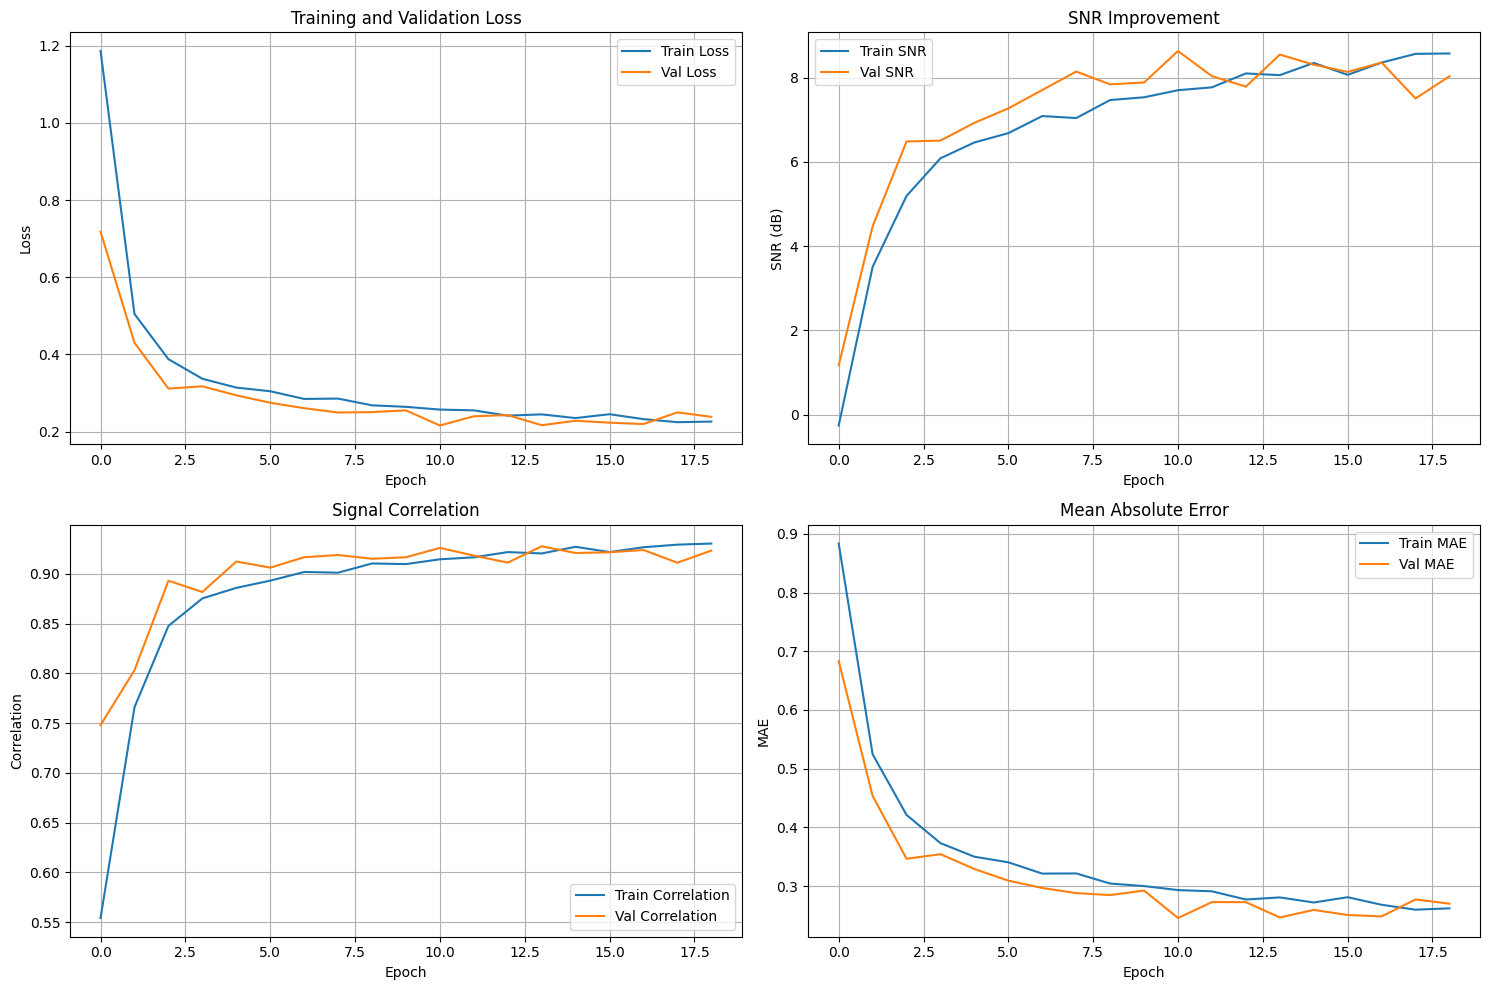

Testing: 100%|██████████| 7/7 [00:11<00:00,  1.71s/it]

✅ Experiment completed successfully!

📊 Final Results Summary:
✅ unet_logmel:
   Best Val Loss: 0.2158
   Final Val SNR: 8.04 dB
   Test SNR: 7.84 dB

💾 Results saved to training_results.json


In [10]:
if __name__ == "__main__":
    print("🚀 Enhanced Speech Enhancement Training Pipeline")
    
    # Configuration
    config = {
        'model_types': ['unet'],  # Can add 'spectral_unet', 'conv_tasnet'
        'feature_types': ['logmel'],       # Can add 'stft', 'mfcc'
        'epochs': 20,
        'batch_size': 16,
        'learning_rate': 1e-3
    }
    
    print("🔧 Configuration:")
    for key, value in config.items():
        print(f"   {key}: {value}")
    
    # Run experiments
    print("\n🧪 Starting experiments...")
    results = run_training_experiment(**config)
    
    # Print final results
    print("\n📊 Final Results Summary:")
    print("=" * 80)
    
    for exp_name, result in results.items():
        if 'error' in result:
            print(f"❌ {exp_name}: FAILED - {result['error']}")
        else:
            print(f"✅ {exp_name}:")
            print(f"   Best Val Loss: {result['best_val_loss']:.4f}")
            if result.get('final_val_snr'):
                print(f"   Final Val SNR: {result['final_val_snr']:.2f} dB")
            if result.get('test_results'):
                test_snr = result['test_results'].get('snr', 0)
                print(f"   Test SNR: {test_snr:.2f} dB")
    
    # Save results
    results_file = 'training_results.json'
    with open(results_file, 'w') as f:
        # Convert any non-serializable objects to strings
        serializable_results = {}
        for key, value in results.items():
            if isinstance(value, dict) and 'history' in value:
                # Convert numpy arrays to lists for JSON serialization
                history = value['history']
                serializable_history = {}
                for h_key, h_value in history.items():
                    if isinstance(h_value, list):
                        serializable_history[h_key] = h_value
                    else:
                        serializable_history[h_key] = str(h_value)
                
                serializable_results[key] = {
                    'history': serializable_history,
                    'best_val_loss': value.get('best_val_loss'),
                    'final_train_snr': value.get('final_train_snr'),
                    'final_val_snr': value.get('final_val_snr'),
                    'test_results': value.get('test_results')
                }
            else:
                serializable_results[key] = value
        
        json.dump(serializable_results, f, indent=2, cls=NumpyEncoder)
    
    print(f"\n💾 Results saved to {results_file}")

In [11]:
feature_dir = "/kaggle/input/voicebank-features/voicebank_features/logmel"
# running on pc
# feature_dir = "voicebank_features/+logmel"


In [12]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = SimpleCNN(input_channels=1, num_classes=num_classes, input_size=(64, 126)).to(device)
#model = UNet(in_channels=1, num_classes=num_classes).to(device)
#criterion = nn.L1Loss()  # Mean Absolute Error works well for spectrogram regression
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=1e-3)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
